In [64]:
import numpy as np
import pint
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
unit = pint.UnitRegistry()

magnitude = lambda x: x.magnitude if isinstance(x, pint.Quantity) else x
tounit = lambda x: lambda y: y.to(x)
assign_unit = lambda x: lambda y: y * x

#usage: data1['L(cm)'].map(tounit(unit.m))
# data1['L(cm)'].map(tounit(unit.m)).map(magnitude)
# data1['L(cm)'].map(tounit(unit.m)).map(magnitude).map(assign_unit(unit.m))

In [4]:
data_table1 = pd.read_csv('../DATA/data_table1.csv')
data_table2 = pd.read_csv('../DATA/data_table2.csv')
data_table3 = pd.read_csv('../DATA/data_table3.csv')

In [5]:
data_table1

,L(cm),Delta_h(cm)
0,22.1,0.0
1,21.5,2.5
2,20.3,6.4
3,19.3,10.3
4,18.5,14.6
5,17.5,18.5
6,16.7,22.7


In [6]:
data_table2

,L(cm),V(ml),T(K)
0,25.3,23.57,303.15
1,25.6,24.34,313.15
2,26.3,25.12,323.15
3,26.8,25.90,333.15


In [7]:
data_table3

,Delta_h(cm),P(kPa),T(K)
0,0.0,100.60,303.15
1,0.7,103.91,313.15
2,1.3,107.22,323.15
3,1.8,110.53,333.15


In [8]:
"""
Set up units of the table contents
"""
# Table 1
data_table1['L(cm)'] = data_table1['L(cm)'].map(assign_unit(unit.cm))
data_table1['Delta_h(cm)'] = data_table1['Delta_h(cm)'].map(assign_unit(unit.cm))

# Table 2 (no P(kPa) column here)
data_table2['L(cm)'] = data_table2['L(cm)'].map(assign_unit(unit.cm))
data_table2['V(ml)'] = data_table2['V(ml)'].map(assign_unit(unit.milliliter))
data_table2['T(K)'] = data_table2['T(K)'].map(assign_unit(unit.K))

# Table 3
data_table3['Delta_h(cm)'] = data_table3['Delta_h(cm)'].map(assign_unit(unit.cm))
data_table3['P(kPa)'] = data_table3['P(kPa)'].map(assign_unit(unit.kPa))
data_table3['T(K)'] = data_table3['T(K)'].map(assign_unit(unit.K))


# Part 1

In [9]:
data_table1['L(cm)']

0    22.1 centimeter
1    21.5 centimeter
2    20.3 centimeter
3    19.3 centimeter
4    18.5 centimeter
5    17.5 centimeter
6    16.7 centimeter
Name: L(cm), dtype: object

In [36]:
"""Set up constants and functions"""
_2r = 11.4 * unit.mm 
r = _2r / 2
A = np.pi * r**2
rho_water = 13595 * unit.kg / unit.m**3
g = 9.81 * unit.m / unit.s**2
p0 = 100.3 * unit.kPa # assumed atmospheric pressure at the location of the experiment, this value is taken from PHYWE series of publication, Laboratory Experiments (setup provider)
T_const = unit.Quantity(30, unit.degC).to(unit.kelvin)  # achieved by the water bath
V_cylinder = lambda l: A.to(unit.m**2) * l.to(unit.m) + (1.01 * unit.milliliter)  # Volume as a function of length
Pressure = lambda h: p0 + rho_water * g * h 
n = 0.9536 * unit.millimole # constant amount of air, taken from PHYWE series of publication, Laboratory Experiments (setup provider)
V_molar = 24.79 * unit.liter / unit.mol # molar volume of air at room temperature and pressure, this value is taken from PHYWE series of publication, Laboratory Experiments (setup provider)
print("The additional 1.01 ml is the volume of the tube section in brown\nthis value is taken from PHYWE series of publication, Laboratory Experiments \n(setup provider)")

The additional 1.01 ml is the volume of the tube section in brown
this value is taken from PHYWE series of publication, Laboratory Experiments 
(setup provider)


In [11]:
data_table1["V(ml)"] = data_table1['L(cm)'].map(tounit(unit.m)).map(V_cylinder).map(tounit(unit.milliliter))
data_table1["V(ml)"] 

0    23.567546314644257 milliliter
1     22.95512424275346 milliliter
2     21.73028009897187 milliliter
3    20.709576645820547 milliliter
4     19.89301388329949 milliliter
5    18.872310430148165 milliliter
6    18.055747667627102 milliliter
Name: V(ml), dtype: object

In [37]:
data_table1["p(kPa)"] = data_table1["Delta_h(cm)"].map(tounit(unit.m)).map(Pressure).map(tounit(unit.kPa))
data_table1["p(kPa)"]

0           100.3 kilopascal
1    103.63417375 kilopascal
2     108.8354848 kilopascal
3    114.03679585 kilopascal
4     119.7715747 kilopascal
5    124.97288575 kilopascal
6    130.57429765 kilopascal
Name: p(kPa), dtype: object

In [13]:
data_table1["R(J/(mol*K))"] = data_table1.apply(lambda row: (row["p(kPa)"] * row["V(ml)"].to(unit.m**3)) / (n* T_const), axis=1).map(tounit(unit.N * unit.m / (unit.mol * unit.K)))

In [14]:
data_table1

,L(cm),Delta_h(cm),V(ml),p(kPa),R(J/(mol*K))
0,22.1 centimeter,0.0 centimeter,23.567546314644257 milliliter,100.3 kilopascal,8.176952732324366 meter * newton / kelvin / mole
1,21.5 centimeter,2.5 centimeter,22.95512424275346 milliliter,103.63417375 kilopascal,8.229222824168762 meter * newton / kelvin / mole
2,20.3 centimeter,6.4 centimeter,21.73028009897187 milliliter,108.8354848 kilopascal,8.181106108910816 meter * newton / kelvin / mole
3,19.3 centimeter,10.3 centimeter,20.709576645820547 milliliter,114.03679585 kilopascal,8.169442346204363 meter * newton / kelvin / mole
4,18.5 centimeter,14.6 centimeter,19.89301388329949 milliliter,119.7715747 kilopascal,8.241960527201185 meter * newton / kelvin / mole
5,17.5 centimeter,18.5 centimeter,18.872310430148165 milliliter,124.97288575 kilopascal,8.158626560465784 meter * newton / kelvin / mole
6,16.7 centimeter,22.7 centimeter,18.055747667627102 milliliter,130.57429765 kilopascal,8.15547686873827 meter * newton / kelvin / mole


In [15]:
mean_R = (data_table1["R(J/(mol*K))"].map(magnitude).mean()) * unit.J / (unit.mol * unit.K)
print(f"Mean R: {mean_R:.2f}")

Mean R: 8.19 joule / kelvin / mole


In [16]:

v_0 = data_table1["V(ml)"].iloc[0] # initial volume from the first row of the table
n_from_V = v_0 / V_molar # function to calculate the amount of substance from volume using molar volume
data_table1["R(J/(mol*K))_n_calculated"] = data_table1.apply(lambda row: (row["p(kPa)"] * row["V(ml)"].to(unit.m**3)) / (n_from_V * T_const), axis=1).map(tounit(unit.joule / (unit.mol * unit.K)))
data_table1["R(J/(mol*K))_n_calculated"]

0    8.202002309087913 joule / kelvin / mole
1     8.25443252704786 joule / kelvin / mole
2    8.206168409280457 joule / kelvin / mole
3    8.194468915375742 joule / kelvin / mole
4    8.267209251226712 joule / kelvin / mole
5    8.183619996162628 joule / kelvin / mole
6    8.180460655554013 joule / kelvin / mole
Name: R(J/(mol*K))_n_calculated, dtype: object

In [17]:
mean_R_n_calculated = (data_table1["R(J/(mol*K))_n_calculated"].map(magnitude).mean()) * unit.J / (unit.mol * unit.K)
print(f"Mean R (n calculated from V): {mean_R_n_calculated:.2f}")

Mean R (n calculated from V): 8.21 joule / kelvin / mole


In [18]:
(n_from_V).to(unit.millimol)

<Quantity(0.950687629, 'millimole')>

In [19]:
n

<Quantity(0.9536, 'millimole')>

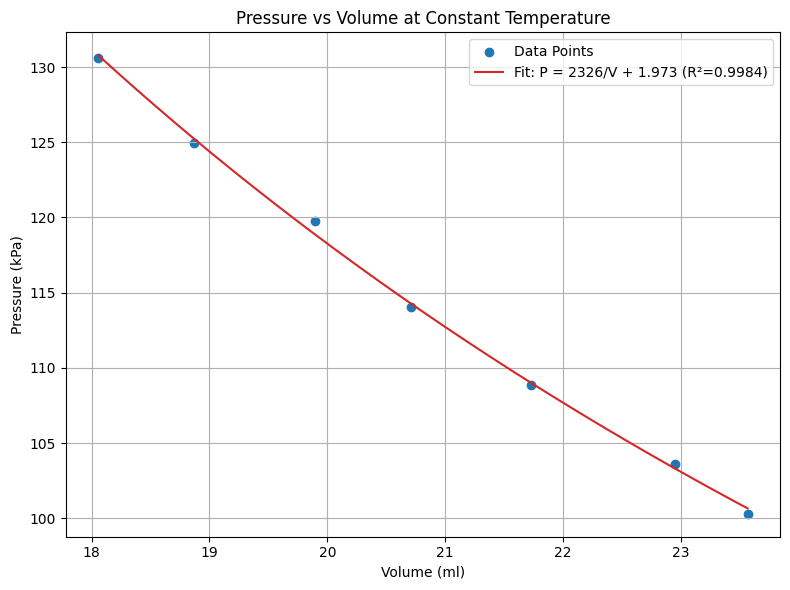

In [69]:
# P-V graph with 1/x fit (Boyle-type): P = a*(1/V) + b
figures_dir = Path("../plots")
figures_dir.mkdir(parents=True, exist_ok=True)

V1_ml = np.asarray(data_table1["V(ml)"].map(magnitude), dtype=float)
P1_kPa = np.asarray(data_table1["p(kPa)"].map(magnitude), dtype=float)

invV1 = 1.0 / V1_ml
slope_boyle_kPa_ml, intercept_boyle_kPa = np.polyfit(invV1, P1_kPa, 1)

P1_pred = slope_boyle_kPa_ml * invV1 + intercept_boyle_kPa
ss_res = np.sum((P1_kPa - P1_pred) ** 2)
ss_tot = np.sum((P1_kPa - np.mean(P1_kPa)) ** 2)
r2_boyle = 1.0 - ss_res / ss_tot

V_fit = np.linspace(V1_ml.min(), V1_ml.max(), 1000)
P_fit = slope_boyle_kPa_ml * (1.0 / V_fit) + intercept_boyle_kPa

plt.figure(figsize=(8, 6))
plt.scatter(V1_ml, P1_kPa, color="tab:blue", label="Data Points")
plt.plot(V_fit, P_fit, color="tab:red", label=f"Fit: P = {slope_boyle_kPa_ml:.4g}/V + {intercept_boyle_kPa:.4g} (R²={r2_boyle:.4f})")
plt.title("Pressure vs Volume at Constant Temperature")
plt.xlabel("Volume (ml)")
plt.ylabel("Pressure (kPa)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "boyle_p_vs_v.png", dpi=300, bbox_inches="tight")
plt.show()

# Part 2

In [34]:
data_table2["V(ml)-calculated"] = data_table2["L(cm)"].map(tounit(unit.m)).map(V_cylinder).map(tounit(unit.milliliter))
data_table2

,L(cm),V(ml),T(K),V(ml)-calculated
0,25.3 centimeter,23.57 milliliter,303.15 kelvin,26.83379736472849 milliliter
1,25.6 centimeter,24.34 milliliter,313.15 kelvin,27.140008400673885 milliliter
2,26.3 centimeter,25.12 milliliter,323.15 kelvin,27.854500817879813 milliliter
3,26.8 centimeter,25.9 milliliter,333.15 kelvin,28.364852544455474 milliliter


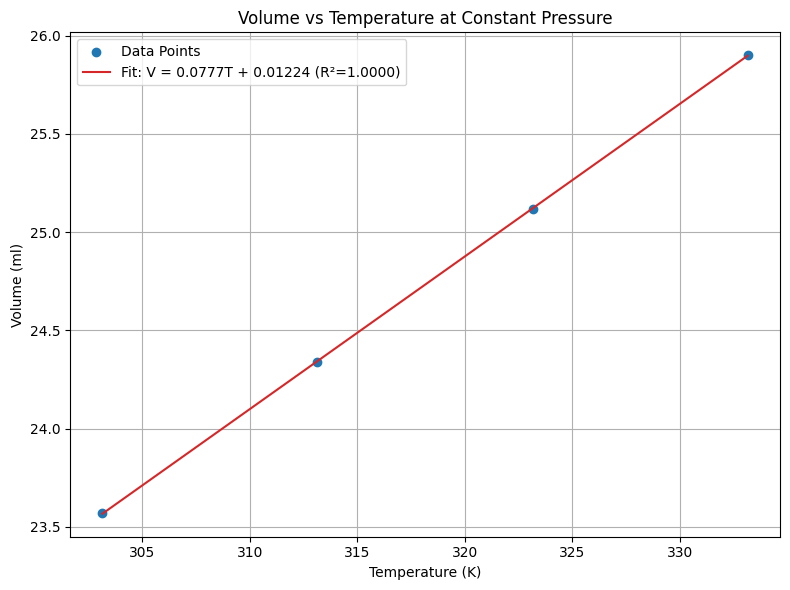

In [70]:
# V-T graph at constant pressure with linear fit: V = a*T + b
figures_dir = Path("../plots")
figures_dir.mkdir(parents=True, exist_ok=True)

T2_K = np.asarray(data_table2["T(K)"].map(magnitude), dtype=float)
V2_ml = np.asarray(data_table2["V(ml)"].map(magnitude), dtype=float)

slope_charles_ml_per_K, intercept_charles_ml = np.polyfit(T2_K, V2_ml, 1)
V2_pred = slope_charles_ml_per_K * T2_K + intercept_charles_ml
ss_res = np.sum((V2_ml - V2_pred) ** 2)
ss_tot = np.sum((V2_ml - np.mean(V2_ml)) ** 2)
r2_charles = 1.0 - ss_res / ss_tot

T_fit = np.linspace(T2_K.min(), T2_K.max(), 1000)
V_fit = slope_charles_ml_per_K * T_fit + intercept_charles_ml

plt.figure(figsize=(8, 6))
plt.scatter(T2_K, V2_ml, color="tab:blue", label="Data Points")
plt.plot(T_fit, V_fit, color="tab:red", label=f"Fit: V = {slope_charles_ml_per_K:.4g}T + {intercept_charles_ml:.4g} (R²={r2_charles:.4f})")
plt.title("Volume vs Temperature at Constant Pressure")
plt.xlabel("Temperature (K)")
plt.ylabel("Volume (ml)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "charles_v_vs_t.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
data_table3["P(kPa)-calculated"] = data_table3["Delta_h(cm)"].map(tounit(unit.m)).map(Pressure).map(tounit(unit.kPa))
data_table3

,Delta_h(cm),P(kPa),T(K),P(kPa)-calculated
0,0.0 centimeter,100.6 kilopascal,303.15 kelvin,100.3 kilopascal
1,0.7 centimeter,103.91 kilopascal,313.15 kelvin,101.23356865 kilopascal
2,1.3 centimeter,107.22 kilopascal,323.15 kelvin,102.03377035 kilopascal
3,1.8 centimeter,110.53 kilopascal,333.15 kelvin,102.7006051 kilopascal


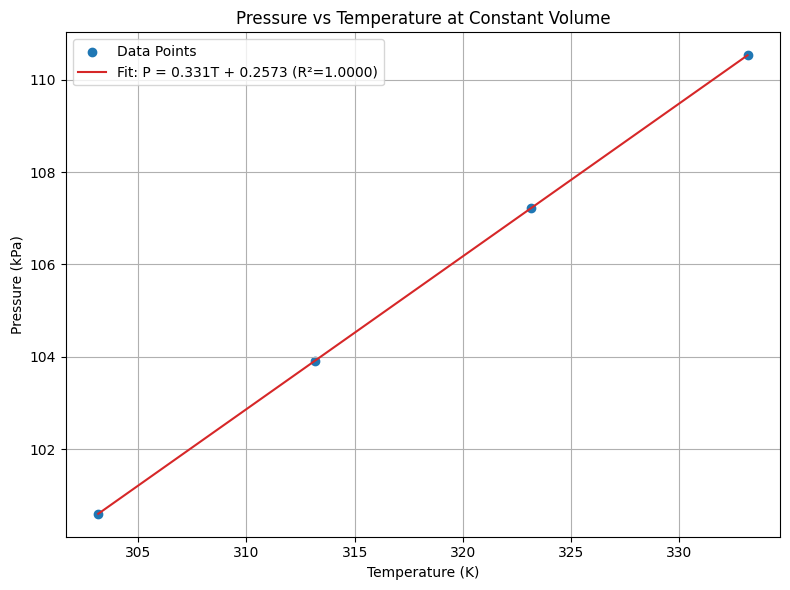

In [71]:
# P-T graph at constant volume with linear fit: P = a*T + b
figures_dir = Path("../plots")
figures_dir.mkdir(parents=True, exist_ok=True)

T3_K = np.asarray(data_table3["T(K)"].map(magnitude), dtype=float)
P3_kPa = np.asarray(data_table3["P(kPa)"].map(magnitude), dtype=float)

slope_amontons_kPa_per_K, intercept_amontons_kPa = np.polyfit(T3_K, P3_kPa, 1)
P3_pred = slope_amontons_kPa_per_K * T3_K + intercept_amontons_kPa
ss_res = np.sum((P3_kPa - P3_pred) ** 2)
ss_tot = np.sum((P3_kPa - np.mean(P3_kPa)) ** 2)
r2_amontons = 1.0 - ss_res / ss_tot

T_fit = np.linspace(T3_K.min(), T3_K.max(), 1000)
P_fit = slope_amontons_kPa_per_K * T_fit + intercept_amontons_kPa

plt.figure(figsize=(8, 6))
plt.scatter(T3_K, P3_kPa, color="tab:blue", label="Data Points")
plt.plot(T_fit, P_fit, color="tab:red", label=f"Fit: P = {slope_amontons_kPa_per_K:.4g}T + {intercept_amontons_kPa:.4g} (R²={r2_amontons:.4f})")
plt.title("Pressure vs Temperature at Constant Volume")
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (kPa)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "amontons_p_vs_t.png", dpi=300, bbox_inches="tight")
plt.show()

In [72]:
# Export processed tables for LaTeX report
tables_dir = Path("../report/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

def q_to_float(value, target_unit=None):
    if hasattr(value, "to") and target_unit is not None:
        return float(value.to(target_unit).magnitude)
    if hasattr(value, "magnitude"):
        return float(value.magnitude)
    return float(value)

t1 = pd.DataFrame({
    "L_cm": data_table1["L(cm)"].map(lambda x: q_to_float(x, unit.cm)),
    "Delta_h_cm": data_table1["Delta_h(cm)"].map(lambda x: q_to_float(x, unit.cm)),
    "V_ml": data_table1["V(ml)"].map(lambda x: q_to_float(x, unit.milliliter)),
    "p_kPa": data_table1["p(kPa)"].map(lambda x: q_to_float(x, unit.kPa)),
    "R_J_per_molK": data_table1["R(J/(mol*K))"].map(lambda x: q_to_float(x, unit.joule / (unit.mol * unit.K))),
})
t1.to_csv(tables_dir / "table1_processed.csv", index=False, float_format="%.6g")

t2 = pd.DataFrame({
    "T_K": data_table2["T(K)"].map(lambda x: q_to_float(x, unit.K)),
    "L_cm": data_table2["L(cm)"].map(lambda x: q_to_float(x, unit.cm)),
    "V_ml": data_table2["V(ml)"].map(lambda x: q_to_float(x, unit.milliliter)),
})
t2.to_csv(tables_dir / "table2_processed.csv", index=False, float_format="%.6g")

t3 = pd.DataFrame({
    "T_K": data_table3["T(K)"].map(lambda x: q_to_float(x, unit.K)),
    "Delta_h_cm": data_table3["Delta_h(cm)"].map(lambda x: q_to_float(x, unit.cm)),
    "P_kPa": data_table3["P(kPa)"].map(lambda x: q_to_float(x, unit.kPa)),
})
t3.to_csv(tables_dir / "table3_processed.csv", index=False, float_format="%.6g")

# Summary values (computed here to avoid relying on execution order)
R_vals = np.asarray(data_table1["R(J/(mol*K))"].map(lambda x: q_to_float(x, unit.joule / (unit.mol * unit.K))), dtype=float)
R_mean = float(np.mean(R_vals))
R_std = float(np.std(R_vals, ddof=1))
R_ref = 8.314462618
R_percent_error = 100.0 * (R_mean - R_ref) / R_ref

# Coefficients (manual Eq. 27/28 style): gamma0 = (1/V0)(dV/dT)|p , beta0 = (1/P0)(dP/dT)|V
T0_K = 273.15
V0_ml_T0 = float(slope_charles_ml_per_K * T0_K + intercept_charles_ml)
P0_kPa_T0 = float(slope_amontons_kPa_per_K * T0_K + intercept_amontons_kPa)
gamma0_per_K = float(slope_charles_ml_per_K / V0_ml_T0)
beta0_per_K = float(slope_amontons_kPa_per_K / P0_kPa_T0)

fit_summary = pd.DataFrame([
    {"relation": "Boyle (P vs 1/V)", "slope": float(slope_boyle_kPa_ml), "intercept": float(intercept_boyle_kPa), "R2": float(r2_boyle)},
    {"relation": "Charles (V vs T)", "slope": float(slope_charles_ml_per_K), "intercept": float(intercept_charles_ml), "R2": float(r2_charles)},
    {"relation": "Amontons (P vs T)", "slope": float(slope_amontons_kPa_per_K), "intercept": float(intercept_amontons_kPa), "R2": float(r2_amontons)},
])
fit_summary.to_csv(tables_dir / "fit_summary.csv", index=False, float_format="%.6g")

report_summary = pd.DataFrame([
    {"quantity": "R_mean_J_per_molK", "value": R_mean},
    {"quantity": "R_std_J_per_molK", "value": R_std},
    {"quantity": "R_reference_J_per_molK", "value": R_ref},
    {"quantity": "R_percent_error", "value": R_percent_error},
    {"quantity": "p0_kPa", "value": q_to_float(p0, unit.kPa)},
    {"quantity": "T_const_K", "value": q_to_float(T_const, unit.K)},
    {"quantity": "n_mmol", "value": q_to_float(n, unit.millimole)},
    {"quantity": "V0_ml_at_T0", "value": V0_ml_T0},
    {"quantity": "P0_kPa_at_T0", "value": P0_kPa_T0},
    {"quantity": "gamma0_per_K", "value": gamma0_per_K},
    {"quantity": "beta0_per_K", "value": beta0_per_K},
])
report_summary.to_csv(tables_dir / "report_summary.csv", index=False, float_format="%.6g")

print("Exported:", *(str(p) for p in [
    tables_dir / "table1_processed.csv",
    tables_dir / "table2_processed.csv",
    tables_dir / "table3_processed.csv",
    tables_dir / "fit_summary.csv",
    tables_dir / "report_summary.csv",
]), sep="\n- ")

Exported:
- ..\report\tables\table1_processed.csv
- ..\report\tables\table2_processed.csv
- ..\report\tables\table3_processed.csv
- ..\report\tables\fit_summary.csv
- ..\report\tables\report_summary.csv
